# **Samsung Mobile Market Analysis using Python**

## **Project Overview**

This project performs Exploratory Data Analysis (EDA) on a Samsung Mobile Phones dataset.

The objective is to understand how different features such as price, RAM, storage, ratings, and Android version are related. Various statistical techniques, visualizations, and machine learning clustering are used to discover meaningful insights from the dataset.

### **Technologies Used**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

### **Dataset**

Samsung Mobiles Dataset (Kaggle)

# **Table of Contents**

## **1. Data Cleaning and Preprocessing**
1.1 Import Libraries

1.2 Load Dataset

1.3 Display Dataset

1.4 Dataset Information

1.5 Dataset Shape

1.6 Check Missing Values

1.7 Check Duplicate Records

1.8 Remove Duplicates

1.9 Statistical Summary

1.10 Data Types

## **2. Exploratory Data Analysis (EDA)**
2.1 Distribution of Mobile Prices

2.2 Distribution of Mobile Ratings

2.3 Price vs RAM

2.4 Price vs Storage

2.5 Price Distribution by RAM

2.6 Average Price by Android Version

2.7 Correlation Heatmap

2.8 Pair Plot

2.9 Price Category Distribution

2.10 Number of Mobiles in Each Price Category

## **3. Machine Learning - Clustering Analysis**
3.1 Selecting Features for Clustering

3.2 Feature Scaling

3.3 Finding the Optimal Number of Clusters (Elbow Method)

3.4 Selecting the Best Number of Clusters (Silhouette Score)

3.5 K-Means Clustering

3.6 Hierarchical Clustering

3.7 DBSCAN Clustering

3.8 Comparison of Clustering Algorithms (Silhouette Scores)

3.9 Cluster Profile Analysis

3.10 PCA Visualization

3.11 Clustering Algorithm Comparison

## **4. Results and Business Insights**

## **5. Conclusion**

## **1.Data Cleaning and Pre-processing**


### **1.1 Import Libraries**

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

### **1.2 Upload Dataset**

In [3]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('/content/SAMSUNGMOBILES (1).csv')

Saving SAMSUNGMOBILES.csv to SAMSUNGMOBILES (2).csv


### **1.3 Display Dataset**

In [5]:
print("First 10  Records")
df.head(10)

First 10  Records


,name,ratings,price,storage,ram,android_version
0,"SAMSUNG Galaxy F13 (Sunrise Copper, 64 GB)",4.3,9499,64,4,12
1,"SAMSUNG Galaxy F13 (Waterfall Blue, 128 GB)",4.3,10499,128,4,12
2,"SAMSUNG Galaxy F13 (Nightsky Green, 128 GB)",4.3,10499,128,4,12
3,"SAMSUNG Galaxy F13 (Sunrise Copper, 128 GB)",4.3,10499,128,4,12
4,"SAMSUNG Galaxy F23 5G (Aqua Blue, 128 GB)",4.3,15499,128,6,12
5,"SAMSUNG Galaxy F23 5G (Forest Green, 128 GB)",4.3,15499,128,6,12
6,"SAMSUNG Galaxy F04 (Jade Purple, 64 GB)",4.2,6999,64,4,12
7,"SAMSUNG Galaxy F04 (Opal Green, 64 GB)",4.2,6999,64,4,12
8,"SAMSUNG Galaxy F14 5G (GOAT Green, 128 GB)",4.2,13990,128,6,13
9,"SAMSUNG Galaxy F23 5G (Copper Blush, 128 GB)",4.3,15499,128,6,12


In [6]:
print("Last 10  Records")
df.tail(10)

Last 10  Records


,name,ratings,price,storage,ram,android_version
397,"SAMSUNG Galaxy M31s (Mirage Blue, 128 GB)",4.1,18999,128,6,9
398,"SAMSUNG Galaxy A32 (Awesome Black, 128 GB)",4.5,24999,128,6,9
399,"SAMSUNG Galaxy F41 (Fusion Black, 128 GB)",4.4,14499,128,6,9
400,"SAMSUNG Galaxy A10s (Black, 32 GB)",4.3,10000,32,2,9
401,"SAMSUNG Galaxy A50 (Blue, 64 GB)",4.2,21000,64,4,8
402,"SAMSUNG Galaxy M40 (Seawater Blue, 128 GB)",4.5,21490,128,6,9
403,"SAMSUNG Galaxy A30s (Prism Crush Violet, 64 GB)",4.3,16199,64,4,12
404,"SAMSUNG Galaxy J4 Plus (Black, 32 GB)",4.4,9000,32,2,8
405,"SAMSUNG Galaxy M01s (Gray, 32 GB)",4.2,10999,32,3,9
406,"SAMSUNG Galaxy S22 (Pink Gold, 128 GB)",4.2,20463,128,8,12


### **1.4 Dataset Information**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             407 non-null    object 
 1   ratings          407 non-null    float64
 2   price            407 non-null    int64  
 3   storage          407 non-null    int64  
 4   ram              407 non-null    int64  
 5   android_version  407 non-null    int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 19.2+ KB


### **1.5 Shape**

In [8]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 407
Columns : 6


### **1.6 Check Missing values**

In [9]:
df.isnull().sum()

,0
name,0
ratings,0
price,0
storage,0
ram,0
android_version,0


### **1.7 Check Duplicate Records**

In [10]:
print("Duplicate Records :", df.duplicated().sum())

Duplicate Records : 0


### **1.8 Remove Duplicates**

In [11]:
df = df.drop_duplicates()
print("New Shape :", df.shape)

New Shape : (407, 6)


### **1.9 Statistical Summary**

In [12]:
df.describe()

,ratings,price,storage,ram,android_version
count,407.00000,407.000000,407.000000,407.000000,407.000000
mean,4.19828,17363.245700,106.199017,5.493857,10.847666
std,0.17762,6735.647203,58.899992,2.185789,1.829261
min,2.90000,6490.000000,1.000000,1.000000,1.000000
25%,4.10000,11982.500000,64.000000,4.000000,10.000000
50%,4.20000,15999.000000,128.000000,6.000000,11.000000
75%,4.30000,21744.500000,128.000000,6.000000,12.000000
max,4.80000,32000.000000,512.000000,12.000000,13.000000


### **1.10 Data Types**

In [13]:
df.dtypes

,0
name,object
ratings,float64
price,int64
storage,int64
ram,int64
android_version,int64


## **2. Exploratory Data Analysis (EDA)**

### **2.1 Distribution of Mobile Prices**

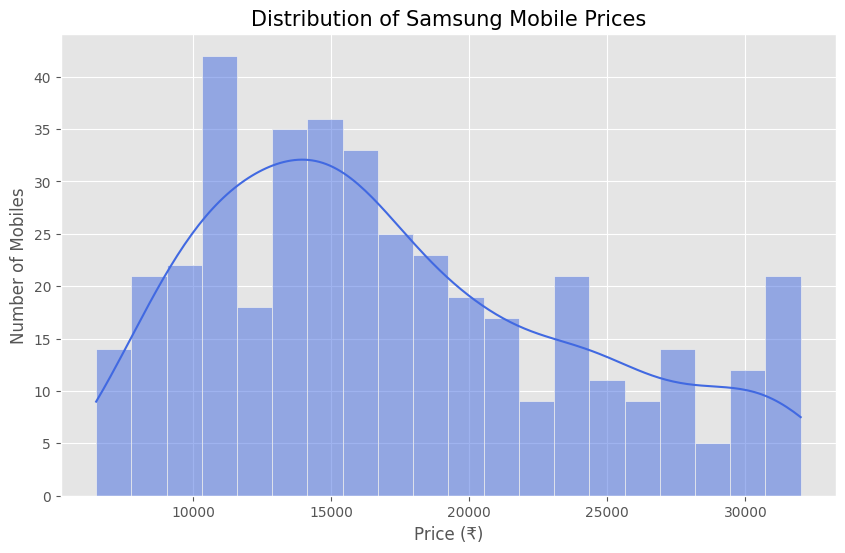

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(df['price'], bins=20, kde=True, color='royalblue')

plt.title("Distribution of Samsung Mobile Prices", fontsize=15)
plt.xlabel("Price (₹)")
plt.ylabel("Number of Mobiles")

plt.show()

### **2.2 Distribution of Ratings**

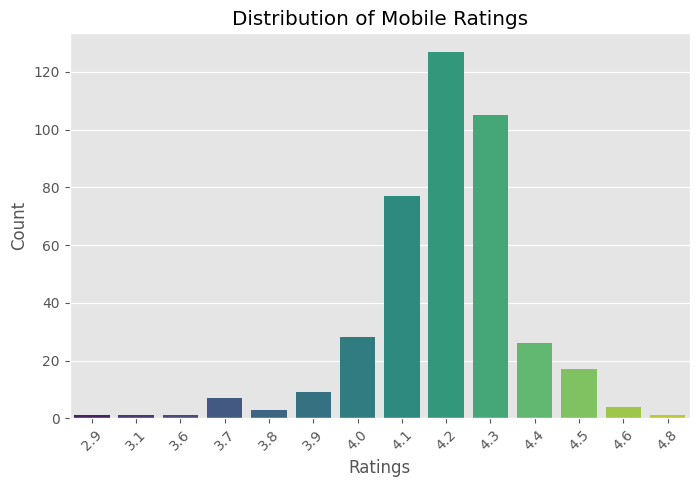

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(x='ratings', data=df, palette='viridis')

plt.title("Distribution of Mobile Ratings")
plt.xlabel("Ratings")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

### **2.3 Price vs RAM**

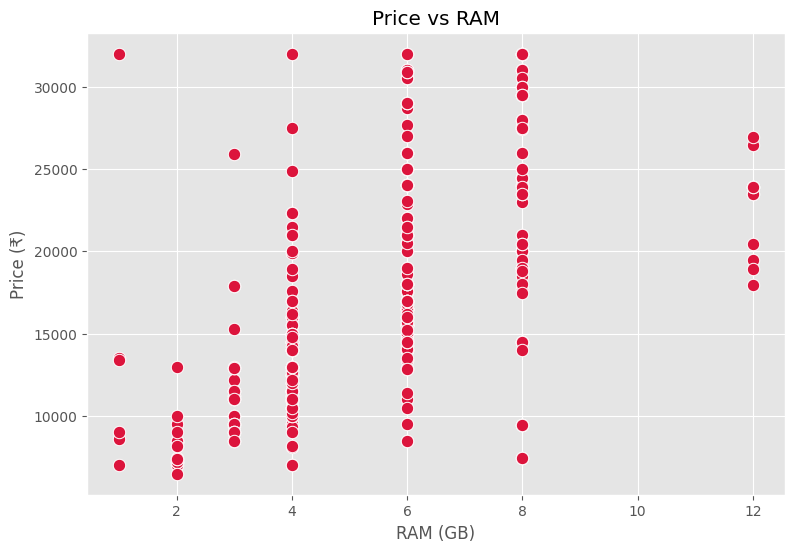

In [16]:
plt.figure(figsize=(9,6))

sns.scatterplot(x='ram',
                y='price',
                data=df,
                color='crimson',
                s=80)

plt.title("Price vs RAM")
plt.xlabel("RAM (GB)")
plt.ylabel("Price (₹)")

plt.show()

### **2.4 Price vs Storage**

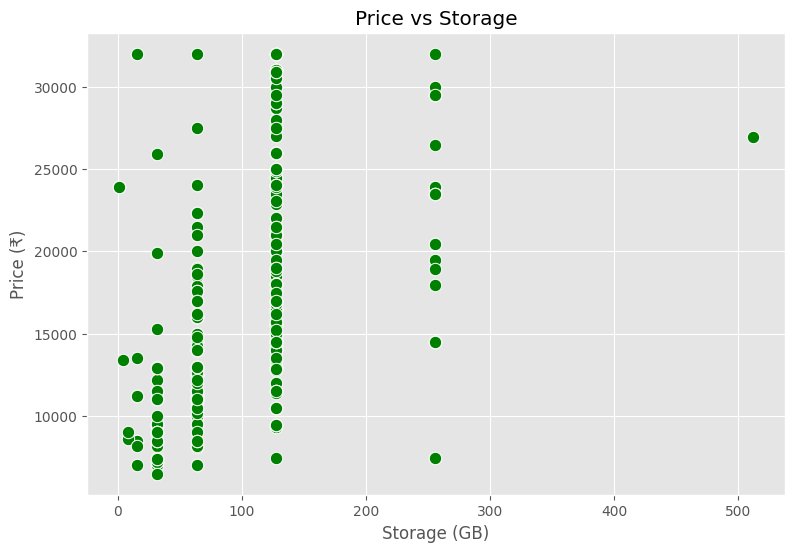

In [17]:
plt.figure(figsize=(9,6))

sns.scatterplot(x='storage',
                y='price',
                data=df,
                color='green',
                s=80)

plt.title("Price vs Storage")
plt.xlabel("Storage (GB)")
plt.ylabel("Price (₹)")

plt.show()

### **2.5 Price Distribution by RAM**

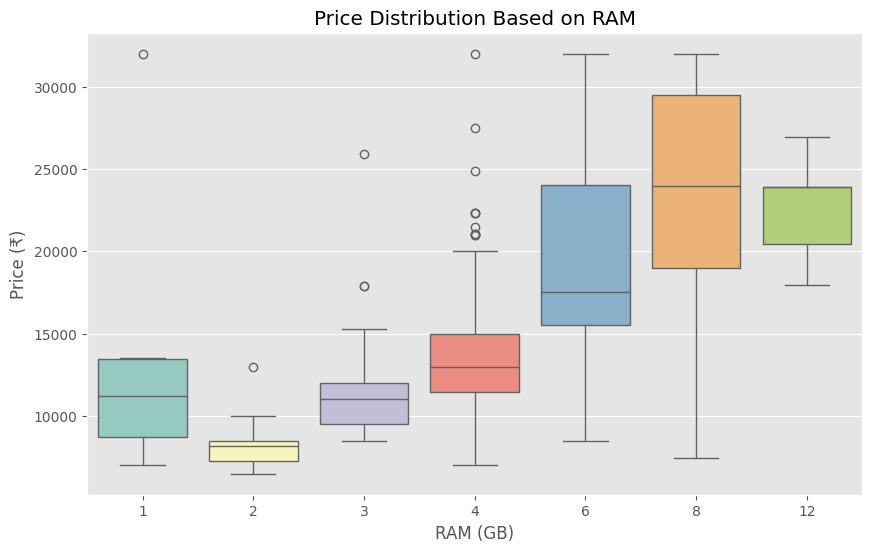

In [21]:
plt.figure(figsize=(10,6))

sns.boxplot(x='ram',
            y='price',
            data=df,
            palette='Set3')

plt.title("Price Distribution Based on RAM")
plt.xlabel("RAM (GB)")
plt.ylabel("Price (₹)")

plt.show()

### **2.6 Average Price by Android Version**

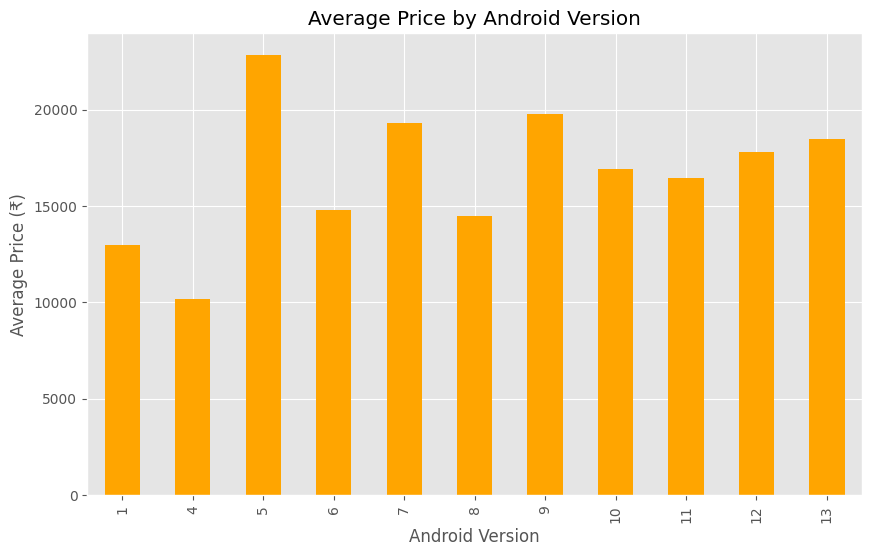

In [22]:
plt.figure(figsize=(10,6))

df.groupby('android_version')['price'].mean().plot(
    kind='bar',
    color='orange'
)

plt.title("Average Price by Android Version")
plt.xlabel("Android Version")
plt.ylabel("Average Price (₹)")

plt.show()

### **2.7 Correlation Heatmap**

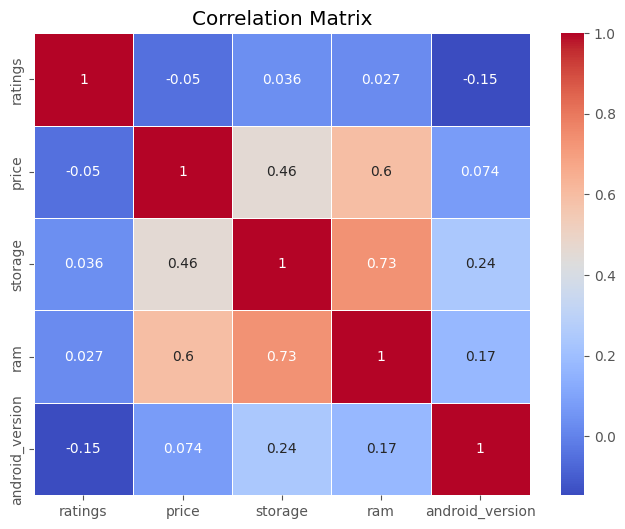

In [23]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Matrix")

plt.show()

### **2.8 Pair Plot**

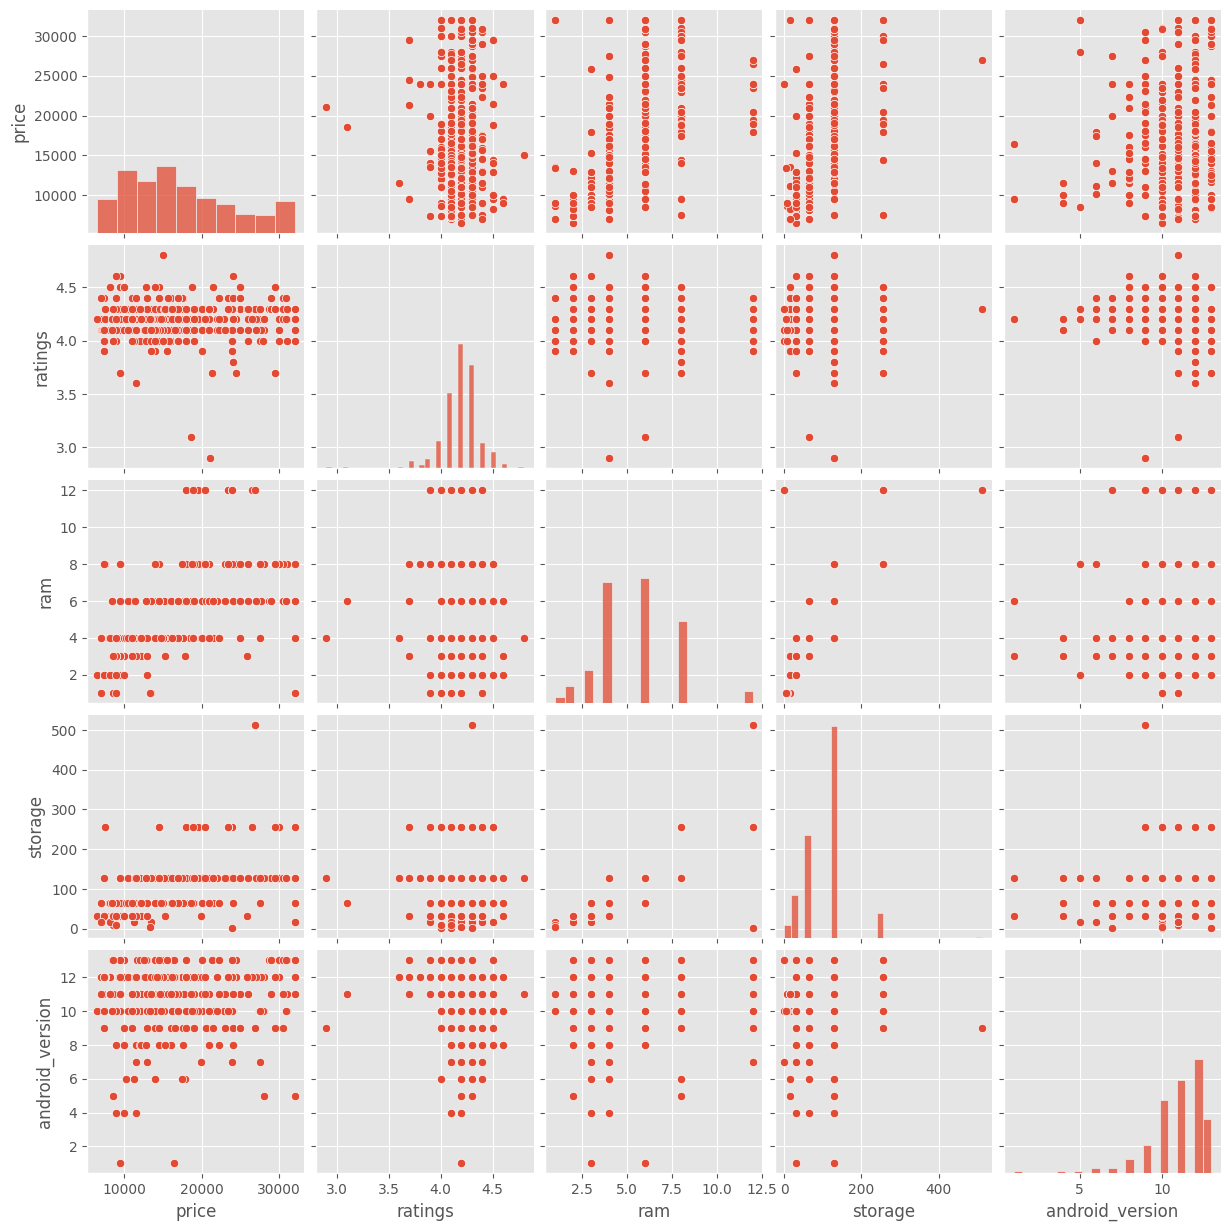

In [24]:
sns.pairplot(
    df[['price',
        'ratings',
        'ram',
        'storage',
        'android_version']]
)

plt.show()

### **2.9 Price Category Distribution**

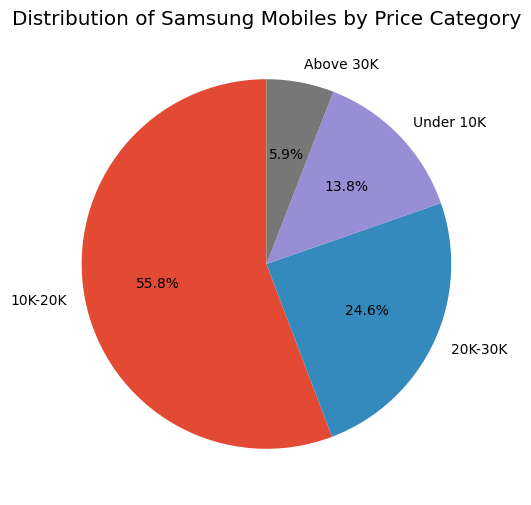

In [25]:
bins=[0,10000,20000,30000,50000]

labels=['Under 10K',
        '10K-20K',
        '20K-30K',
        'Above 30K']

df['Price_Category']=pd.cut(df['price'],
                            bins=bins,
                            labels=labels)

plt.figure(figsize=(8,6))

df['Price_Category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.ylabel("")

plt.title("Distribution of Samsung Mobiles by Price Category")

plt.show()

### **2.10 Number of Mobiles in Each Price Category**

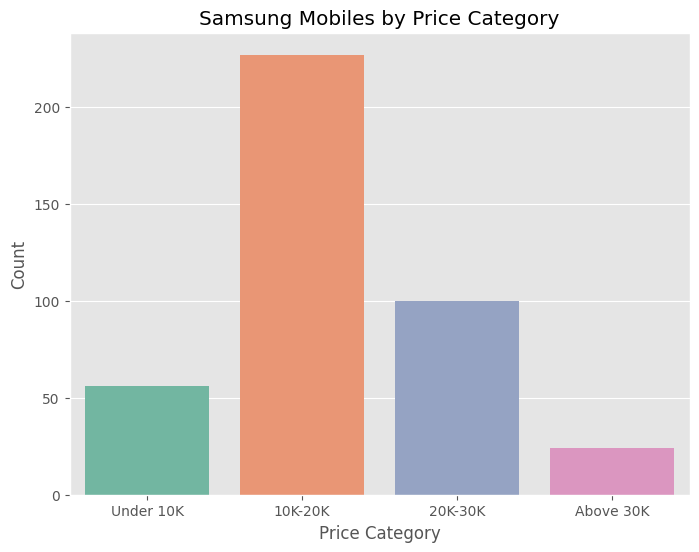

In [27]:
plt.figure(figsize=(8,6))

sns.countplot(
    x='Price_Category',
    data=df,
    palette='Set2'
)

plt.title("Samsung Mobiles by Price Category")

plt.xlabel("Price Category")
plt.ylabel("Count")

plt.show()

## **3. Machine Learning - Clustering Analysis**

### **3.1 Selecting Features for Clustering**

In [28]:
# Selecting numerical features for clustering
features = df[['price',
               'ratings',
               'ram',
               'storage',
               'android_version']]

features.head()

,price,ratings,ram,storage,android_version
0,9499,4.3,4,64,12
1,10499,4.3,4,128,12
2,10499,4.3,4,128,12
3,10499,4.3,4,128,12
4,15499,4.3,6,128,12


### **3.2 Feature Scaling**

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_df = pd.DataFrame(scaled_features,
                         columns=features.columns)

scaled_df.head()

,price,ratings,ram,storage,android_version
0,-1.168993,0.573389,-0.684282,-0.717334,0.630721
1,-1.020346,0.573389,-0.684282,0.370591,0.630721
2,-1.020346,0.573389,-0.684282,0.370591,0.630721
3,-1.020346,0.573389,-0.684282,0.370591,0.630721
4,-0.277114,0.573389,0.231846,0.370591,0.630721


### **3.3 Finding the Optimal Number of Clusters (Elbow Method)**

In [30]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_df)
    wcss.append(model.inertia_)

### **Plot the Elbow Curve**

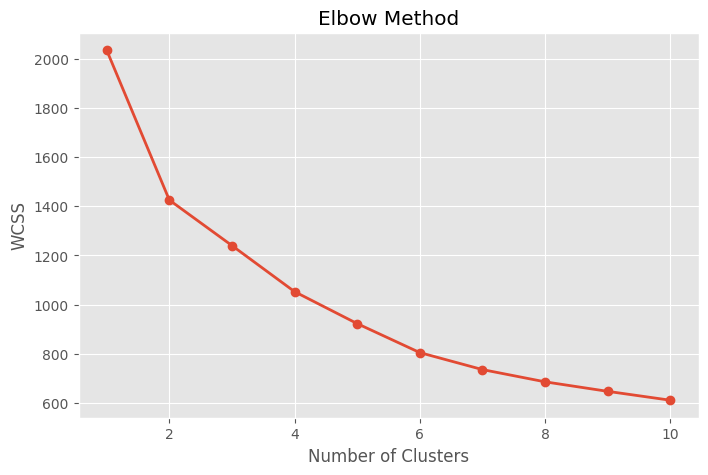

In [31]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11),
         wcss,
         marker='o',
         linewidth=2)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.grid(True)
plt.show()

### **3.4 Selecting the Best Number of Clusters using Silhouette Score**

In [32]:
from sklearn.metrics import silhouette_score
scores = []
for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(scaled_df)

    score = silhouette_score(scaled_df, labels)

    scores.append(score)

### **Plot Silhouette Score**

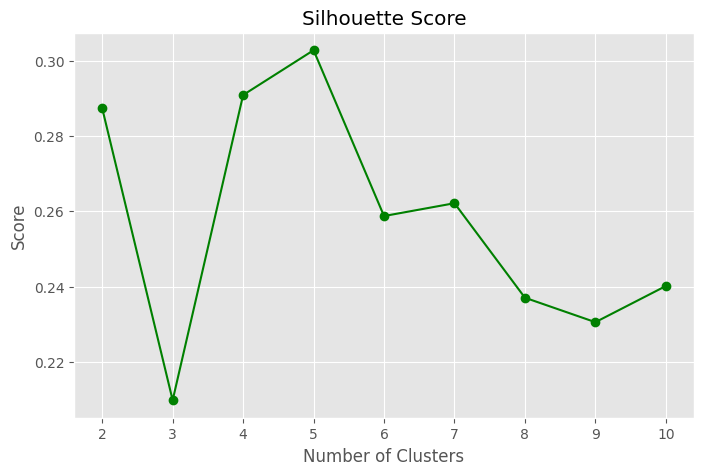

Best Number of Clusters : 5


In [33]:
plt.figure(figsize=(8,5))
plt.plot(range(2,11),
         scores,
         marker='o',
         color='green')

plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Score")

plt.grid(True)
plt.show()

best_k = scores.index(max(scores)) + 2
print("Best Number of Clusters :", best_k)

### **Selection of Optimal Number of Clusters**

The optimal number of clusters was determined using the Elbow Method and Silhouette Score analysis.

- The Elbow Method indicated that the reduction in WCSS began to stabilize around **4–5 clusters**.
- The Silhouette Score achieved its highest value at **k = 5**, indicating better cluster separation and cohesion.

Therefore, **5 clusters** were selected for performing K-Means Clustering.

### **3.5 K-Means Clustering**

K-Means is an unsupervised machine learning algorithm that groups similar data points into clusters based on their feature similarity. Using the optimal number of clusters (k = 5), the Samsung mobile dataset is segmented to identify groups with similar characteristics such as price, RAM, storage, ratings, and Android version.

In [34]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(scaled_df)

df.head()

,name,ratings,price,storage,ram,android_version,Price_Category,KMeans_Cluster
0,"SAMSUNG Galaxy F13 (Sunrise Copper, 64 GB)",4.3,9499,64,4,12,Under 10K,1
1,"SAMSUNG Galaxy F13 (Waterfall Blue, 128 GB)",4.3,10499,128,4,12,10K-20K,1
2,"SAMSUNG Galaxy F13 (Nightsky Green, 128 GB)",4.3,10499,128,4,12,10K-20K,1
3,"SAMSUNG Galaxy F13 (Sunrise Copper, 128 GB)",4.3,10499,128,4,12,10K-20K,1
4,"SAMSUNG Galaxy F23 5G (Aqua Blue, 128 GB)",4.3,15499,128,6,12,10K-20K,2


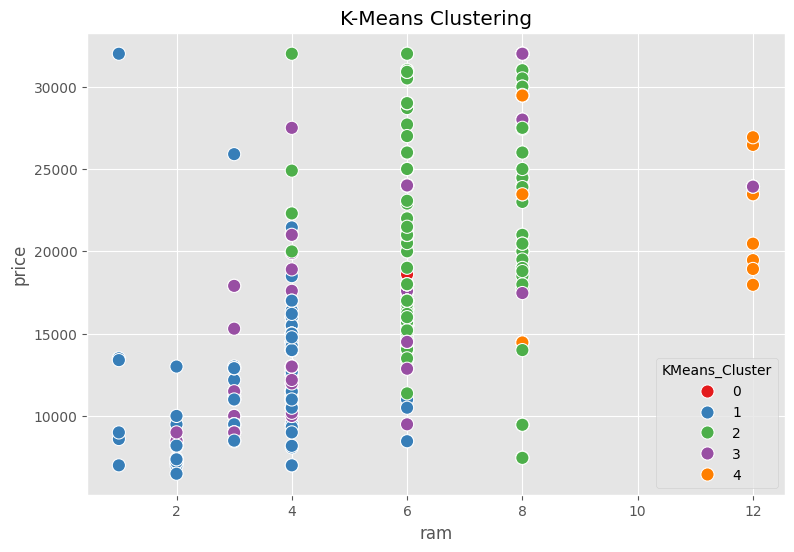

In [35]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    x='ram',
    y='price',
    hue='KMeans_Cluster',
    data=df,
    palette='Set1',
    s=90
)

plt.title("K-Means Clustering")
plt.show()

### **3.6 Hierarchical Clustering**

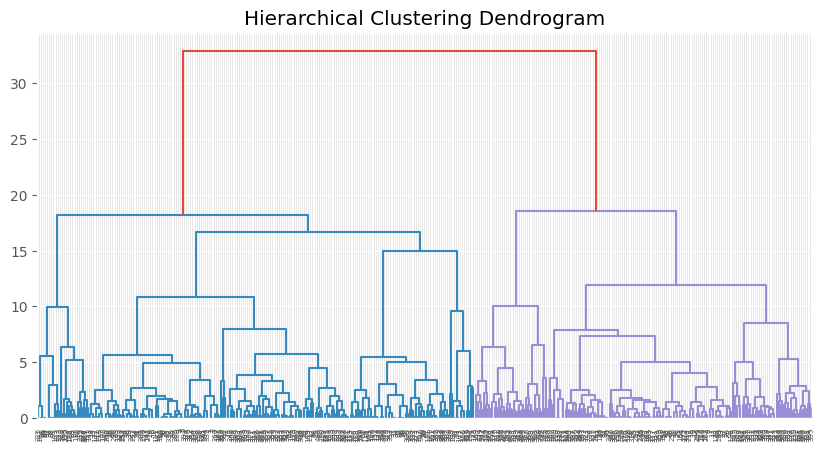

In [36]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(scaled_df, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

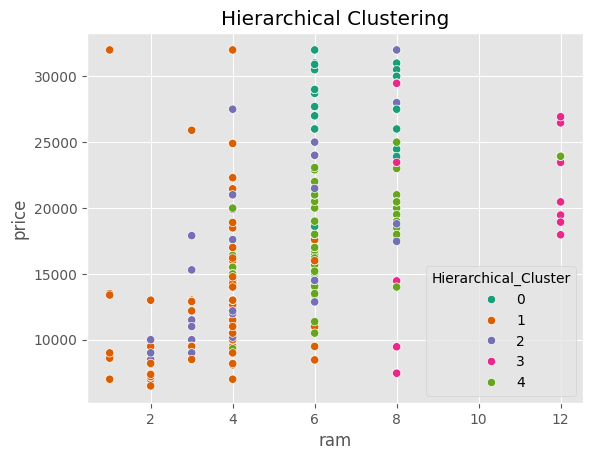

In [39]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=5)

df['Hierarchical_Cluster'] = hc.fit_predict(scaled_df)

sns.scatterplot(
    x='ram',
    y='price',
    hue='Hierarchical_Cluster',
    data=df,
    palette='Dark2'
)

plt.title("Hierarchical Clustering")
plt.show()

### **3.7 DBSCAN Clustering**

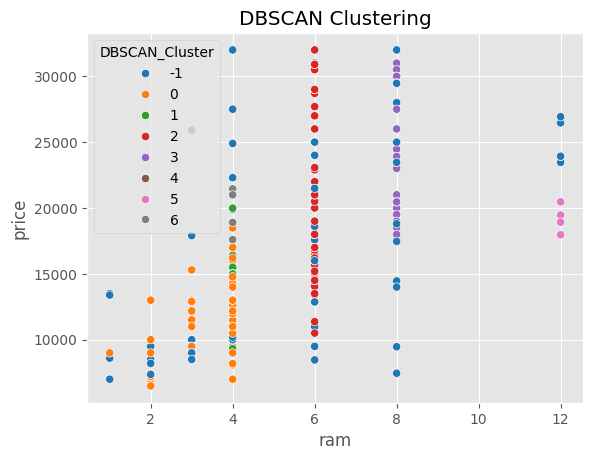

In [40]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=0.8, min_samples=5)

df['DBSCAN_Cluster'] = db.fit_predict(scaled_df)

sns.scatterplot(
    x='ram',
    y='price',
    hue='DBSCAN_Cluster',
    data=df,
    palette='tab10'
)

plt.title("DBSCAN Clustering")
plt.show()

### **3.8 Comparison of Clustering Algorithms**

In [41]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(scaled_df, df['KMeans_Cluster'])
hc_score = silhouette_score(scaled_df, df['Hierarchical_Cluster'])

print("K-Means Silhouette Score :", round(kmeans_score,3))
print("Hierarchical Silhouette Score :", round(hc_score,3))

if len(set(df['DBSCAN_Cluster'])) > 1:
    db_score = silhouette_score(scaled_df, df['DBSCAN_Cluster'])
    print("DBSCAN Silhouette Score :", round(db_score,3))
else:
    print("DBSCAN did not form meaningful clusters.")

K-Means Silhouette Score : 0.303
Hierarchical Silhouette Score : 0.225
DBSCAN Silhouette Score : 0.024


### **3.9 Cluster Profile Table**
#### **Cluster Profile Analysis**

The average characteristics of each cluster are calculated to better understand the similarities and differences among Samsung mobile groups.

In [42]:
cluster_profile = df.groupby('KMeans_Cluster')[[
    'price',
    'ram',
    'storage',
    'ratings',
    'android_version'
]].mean().round(2)

cluster_profile

,price,ram,storage,ratings,android_version
KMeans_Cluster,,,,,
0,22829.85,7.08,142.77,3.62,11.92
1,12180.70,3.57,65.84,4.18,11.25
2,21175.18,6.66,124.38,4.22,11.24
3,15956.30,4.56,68.49,4.31,6.98
4,21199.84,9.60,266.24,4.29,11.76


### **3.10 PCA Visualization**

Principal Component Analysis (PCA) is used to reduce the dimensionality of the dataset to two principal components, allowing the clusters formed by K-Means to be visualized more effectively.

In [43]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_df)
pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = df['KMeans_Cluster']

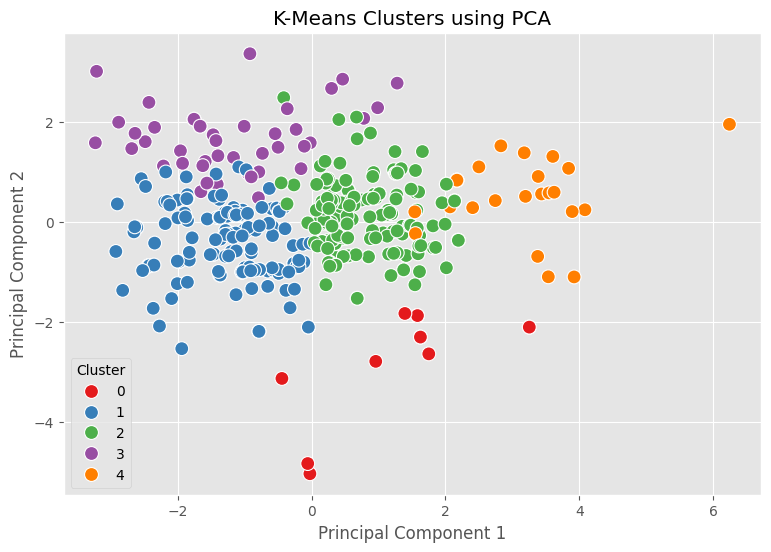

In [44]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title("K-Means Clusters using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

### **3.11 Clustering Algorithm Comparison**

The performance of different clustering algorithms is compared using the Silhouette Score.

In [47]:
comparison = pd.DataFrame({
    'Algorithm': [
        'K-Means',
        'Hierarchical',
        'DBSCAN'
    ],
    'Silhouette Score': [
        kmeans_score,
        hc_score,
        db_score
    ]
})
comparison

,Algorithm,Silhouette Score
0,K-Means,0.302841
1,Hierarchical,0.224531
2,DBSCAN,0.023991


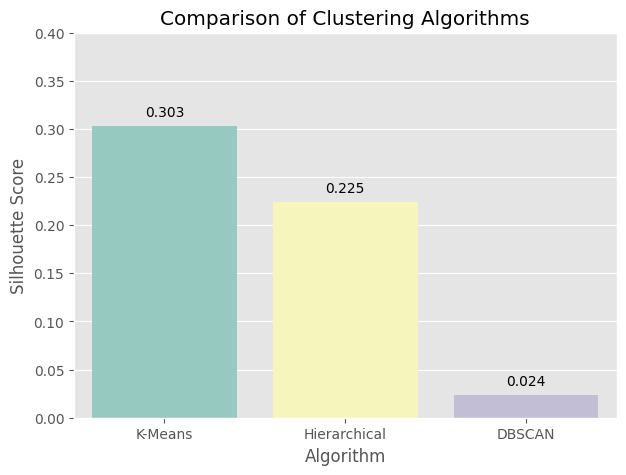

In [48]:
plt.figure(figsize=(7,5))
sns.barplot(
    data=comparison,
    x='Algorithm',
    y='Silhouette Score',
    palette='Set3'
)

plt.title("Comparison of Clustering Algorithms")
plt.ylim(0,0.4)

for index, value in enumerate(comparison['Silhouette Score']):
    plt.text(index, value+0.01, round(value,3), ha='center')
plt.show()

## **4. Results and Business Insights**

After comparing three clustering algorithms, the following observations were made:

- K-Means achieved the highest Silhouette Score (0.303), indicating the best cluster separation.
- Hierarchical Clustering produced meaningful clusters but with lower performance.
- DBSCAN was not suitable for this dataset because it struggled to identify well-defined clusters.

Based on these results, K-Means was selected as the most effective clustering algorithm for segmenting Samsung mobile phones.

The clustering analysis can help identify groups of smartphones with similar specifications, pricing, and storage capacity, which may assist businesses in product categorization and market segmentation.

## **5. Conclusion**

This project successfully analyzed the Samsung Mobile dataset using Exploratory Data Analysis (EDA) and unsupervised machine learning techniques.

Different clustering algorithms were compared, and K-Means was found to be the most suitable method based on the Silhouette Score.

The project demonstrates practical applications of Python, data visualization, feature scaling, clustering, and model evaluation in solving real-world data analysis problems.

# **Thank You**
Thank you for reviewing this project.

This notebook demonstrates the application of Exploratory Data Analysis (EDA) and Unsupervised Machine Learning techniques on the Samsung Mobile dataset. It covers data preprocessing, visualization, clustering, model evaluation, and business insights to identify meaningful patterns in the data.

Future Improvements

- Explore additional clustering algorithms.
- Build an interactive dashboard using Tableau or Power BI.
- Analyze larger and more diverse smartphone datasets.

Thank you!